# DoubleAE codes from audio files

Load a DoubleAE training checkpoint, encode darbouka examples into separate fast and slow codes, recombine the branches, and decode them back to audio.


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if not (repo_root / "after").exists() and (repo_root.parent / "after").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import cached_conv as cc
import gin
import librosa
import numpy as np

import torch
import torchaudio
from IPython.display import Audio, display

torch.set_grad_enabled(False)
cc.use_cached_conv(False)


## Paths and options


In [4]:
# Folder containing config.gin and checkpoint*.pt files.
model_dir = repo_root / "autoencoder_runs" / "doubleAE_darbouka_asym_freeze"

# Use None for the latest checkpoint in model_dir, or set an integer step.
checkpoint_step = None

# Audio files to encode and recombine.
audio_paths = {
    "darbouka3": repo_root / "perso" / "darbouka3.wav",
    "darbouka1": repo_root / "perso" / "darbouka1.wav",
}

reference_example = "darbouka3"

device = "cuda:0" if torch.cuda.is_available() else "cpu"
audio_channels = 1  # Set to 2 for a stereo DoubleAE checkpoint.
max_seconds = None  # Optional: e.g. 10.0 to load only the first 10 seconds.


## Load the checkpoint


In [ ]:
def find_checkpoint(model_dir, step=None):
    model_dir = Path(model_dir).expanduser().resolve()
    if step is not None:
        ckpt = model_dir / f"checkpoint{step}.pt"
        if not ckpt.exists():
            raise FileNotFoundError(ckpt)
        return ckpt

    checkpoints = []
    for path in model_dir.glob("checkpoint*.pt"):
        try:
            checkpoints.append((int(path.stem.replace("checkpoint", "")), path))
        except ValueError:
            pass
    if not checkpoints:
        raise FileNotFoundError(f"No checkpoint*.pt files found in {model_dir}")
    return max(checkpoints, key=lambda item: item[0])[1]


def load_doubleae(model_dir, step=None, device="cpu", audio_channels=1):
    model_dir = Path(model_dir).expanduser().resolve()
    config_path = model_dir / "config.gin"
    checkpoint_path = find_checkpoint(model_dir, step)
    if not config_path.exists():
        raise FileNotFoundError(config_path)

    gin.clear_config()
    gin.enter_interactive_mode()
    gin.parse_config_files_and_bindings([str(config_path)], [])
    with gin.unlock_config():
        gin.bind_parameter("%AUDIO_CHANNELS", audio_channels)

    from after.autoencoder.networks.DoubleNet import DoubleAE

    model = DoubleAE().to(device).eval()
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    state_dict = checkpoint.get("model_state", checkpoint)
    model.load_state_dict(state_dict, strict=False)

    sample_rate = gin.query_parameter("%SR")
    return model, sample_rate, checkpoint_path


model, sample_rate, checkpoint_path = load_doubleae(
    model_dir,
    step=checkpoint_step,
    device=device,
    audio_channels=audio_channels,
)

print(f"Loaded {checkpoint_path}")
print(f"sample_rate={sample_rate}, device={device}")
print(f"fast code channels={model.fast_encoder.bottleneck_size}")
print(f"slow code channels={model.slow_encoder.bottleneck_size}")


## Load audio examples


In [ ]:
def load_audio_tensor(path, sample_rate, audio_channels=1, device="cpu", max_seconds=None):
    path = Path(path).expanduser().resolve()
    if audio_channels == 1:
        wav, _ = librosa.load(path, sr=sample_rate, mono=True, duration=max_seconds)
        wav = wav[None, :]
    else:
        wav, _ = librosa.load(path, sr=sample_rate, mono=False, duration=max_seconds)
        if wav.ndim == 1:
            wav = np.repeat(wav[None, :], audio_channels, axis=0)
        elif wav.shape[0] < audio_channels:
            wav = np.repeat(wav[:1], audio_channels, axis=0)
        else:
            wav = wav[:audio_channels]

    x = torch.from_numpy(np.asarray(wav, dtype=np.float32)).unsqueeze(0)
    return x.to(device), path


examples = {}
target_samples = None
for name, path in audio_paths.items():
    x_i, resolved_path = load_audio_tensor(
        path,
        sample_rate,
        audio_channels=audio_channels,
        device=device,
        max_seconds=max_seconds,
    )
    examples[name] = {"audio": x_i, "path": resolved_path}
    target_samples = x_i.shape[-1] if target_samples is None else min(target_samples, x_i.shape[-1])

# Matching lengths keeps fast/slow latent time dimensions compatible for cross-decoding.
for example in examples.values():
    example["audio"] = example["audio"][..., :target_samples]

for name, example in examples.items():
    print(f"{name}: {example['path']}")
    print(f"{name} shape: {tuple(example['audio'].shape)}")
    display(Audio(example["audio"][0].detach().cpu().numpy(), rate=sample_rate))

x = examples[reference_example]["audio"]
audio_path = examples[reference_example]["path"]


## Encode fast and slow codes


In [ ]:
codes = {}
with torch.no_grad():
    for name, example in examples.items():
        z_fast_i, z_slow_i, regloss_i = model.encode_codes(example["audio"])
        z_combined_i = model.combine_codes(z_fast_i, z_slow_i)
        z_fast_aligned_i, z_slow_aligned_i = model.split_codes(z_combined_i)
        codes[name] = {
            "fast": z_fast_i,
            "slow": z_slow_i,
            "combined": z_combined_i,
            "fast_aligned": z_fast_aligned_i,
            "slow_aligned": z_slow_aligned_i,
            "regloss": regloss_i,
        }

for name, code_i in codes.items():
    print(name)
    print(f"  z_fast raw:      {tuple(code_i['fast'].shape)}")
    print(f"  z_slow raw:      {tuple(code_i['slow'].shape)}")
    print(f"  z_combined:      {tuple(code_i['combined'].shape)}")
    print(f"  z_fast aligned:  {tuple(code_i['fast_aligned'].shape)}")
    print(f"  z_slow aligned:  {tuple(code_i['slow_aligned'].shape)}")
    print(f"  regloss: {float(code_i['regloss'].detach().cpu()):.6g}")

# Backwards-compatible aliases for quick one-off cells.
z_fast = codes[reference_example]["fast"]
z_slow = codes[reference_example]["slow"]
z_combined = codes[reference_example]["combined"]
z_fast_aligned = codes[reference_example]["fast_aligned"]
z_slow_aligned = codes[reference_example]["slow_aligned"]
regloss = codes[reference_example]["regloss"]


For VAE checkpoints, you can also inspect branch means directly.


In [ ]:
for name, example in examples.items():
    try:
        z_fast_sample, fast_regloss, z_fast_mean = model.encode_fast(example["audio"], return_mean=True)
        z_slow_sample, slow_regloss, z_slow_mean = model.encode_slow(example["audio"], return_mean=True)
        codes[name]["fast_mean"] = z_fast_mean
        codes[name]["slow_mean"] = z_slow_mean
        codes[name]["fast_regloss"] = fast_regloss
        codes[name]["slow_regloss"] = slow_regloss
        print(name)
        print(f"  z_fast_mean: {tuple(z_fast_mean.shape)}")
        print(f"  z_slow_mean: {tuple(z_slow_mean.shape)}")
        print(f"  fast_regloss: {float(fast_regloss.detach().cpu()):.6g}")
        print(f"  slow_regloss: {float(slow_regloss.detach().cpu()):.6g}")
    except Exception as exc:
        print(f"{name}: branch means are not available for this bottleneck: {exc}")


## Decode reconstructions


In [ ]:
def to_audio_display(wav):
    wav = wav.detach().cpu().clamp(-1, 1)
    return wav[0].numpy()


def display_audio_map(audio_map):
    for name, wav in audio_map.items():
        print(name)
        display(Audio(to_audio_display(wav), rate=sample_rate))


reconstructions = {}
with torch.no_grad():
    for name, code_i in codes.items():
        reconstructions[f"{name}_reconstruction"] = model.decode_codes(code_i["fast"], code_i["slow"])

# Backwards-compatible aliases for the reference example.
y_from_codes = reconstructions[f"{reference_example}_reconstruction"]
y_from_combined = model.decode(codes[reference_example]["combined"])

print(f"decoded shape: {tuple(y_from_codes.shape)}")
display_audio_map(reconstructions)


## Cross fast and slow codes


In [ ]:
name_a = "darbouka3"
name_b = "darbouka1"

cross_decodes = {}
with torch.no_grad():
    cross_decodes[f"fast_{name_a}_slow_{name_b}"] = model.decode_codes(
        codes[name_a]["fast"], codes[name_b]["slow"]
    )
    cross_decodes[f"fast_{name_b}_slow_{name_a}"] = model.decode_codes(
        codes[name_b]["fast"], codes[name_a]["slow"]
    )

display_audio_map(cross_decodes)


## Random and zero branch controls


In [ ]:
control_decodes = {}
with torch.no_grad():
    for name, code_i in codes.items():
        fast = code_i["fast"]
        slow = code_i["slow"]
        control_decodes[f"{name}_fast_randn_slow"] = model.decode_codes(
            fast, torch.randn_like(slow)
        )
        control_decodes[f"{name}_zero_fast_slow"] = model.decode_codes(
            torch.zeros_like(fast), slow
        )
        control_decodes[f"{name}_fast_zero_slow"] = model.decode_codes(
            fast, torch.zeros_like(slow)
        )
        control_decodes[f"{name}_zero_fast_zero_slow"] = model.decode_codes(
            torch.zeros_like(fast), torch.zeros_like(slow)
        )

# Backwards-compatible aliases for the reference example.
y_fast_only = control_decodes[f"{reference_example}_fast_randn_slow"]
y_slow_only = control_decodes[f"{reference_example}_zero_fast_slow"]

display_audio_map(control_decodes)


## Save reconstructions


In [ ]:
out_dir = repo_root / "notebooks" / "doubleae_outputs"
out_dir.mkdir(parents=True, exist_ok=True)

all_outputs = {}
all_outputs.update(reconstructions)
all_outputs.update(cross_decodes)
all_outputs.update(control_decodes)

for name, wav in all_outputs.items():
    torchaudio.save(
        str(out_dir / f"{name}.wav"),
        wav[0].detach().cpu().clamp(-1, 1),
        sample_rate,
    )

print(out_dir)
print(f"saved {len(all_outputs)} files")


## Compare checkpoint and TorchScript forward

Generate the same darbouka audio four ways: normal offline generation from the already-loaded checkpoint model, TorchScript decoding of the checkpoint latents, one-call generation from the streaming TorchScript model, and chunk-by-chunk generation from the same streaming TorchScript model.


In [118]:
from after_scripts.export_double_autoencoder import (
    export_double_autoencoder,
    reset_stream_state,
)

compare_name = "darbouka3"
x_compare = examples[compare_name]["audio"].detach().cpu()[...,:16384]
original_samples = x_compare.shape[-1]

# Match the exported forward chunk size: slow STFT hop times slow encoder time strides.

chunk_size_slow = chunk_size =  4096
chunk_size_fast = model.fast_encoder.time_transform.hop_size
for layer in model.slow_encoder.down_layers:
    chunk_size *= layer.proj_pool.stride[1]

pad = (-x_compare.shape[-1]) % chunk_size
x_compare_padded =  x_compare

# 1) Normal generation with the checkpoint model already loaded earlier in this notebook.
# Keep the exact combined checkpoint latents so the TorchScript decoder can be tested alone.
cc.use_cached_conv(False)
torch.manual_seed(1234)
with torch.no_grad():
    x_compare_device = x_compare_padded.to(device)
    checkpoint_latents, checkpoint_regloss = model.encode(x_compare_device)
    checkpoint_forward_normal = model.decode(checkpoint_latents).detach().cpu()
checkpoint_latents = checkpoint_latents.detach().cpu()

# Export or refresh the streaming TorchScript model from the same checkpoint directory.
# torchscript_path = Path(export_double_autoencoder(
#     str(model_dir),
#     step=checkpoint_step,
#     output_name="double_export_stream.ts",
# ))

torchscript_path = "/data/nils/repos/AFTER/autoencoder_runs/doubleAE_darbouka_asym_freeze/double_export_slow.ts"
torchscript_stream = torch.jit.load(str(torchscript_path)).eval()

torchscript_path_fast = "/data/nils/repos/AFTER/autoencoder_runs/doubleAE_darbouka_asym_freeze/double_export_fast.ts"
torchscript_stream_fast = torch.jit.load(str(torchscript_path_fast)).eval()

# 2) Decode the Python checkpoint latents with the streaming TorchScript decoder.
reset_stream_state(torchscript_stream)
with torch.no_grad():
    torchscript_decode_checkpoint_latents = torchscript_stream.decode(
        checkpoint_latents,
    ).detach().cpu()[..., :original_samples]


# 5) One big chunk generation with the streaming TorchScript model.
reset_stream_state(torchscript_stream)
reset_stream_state(torchscript_stream_fast)
torch.manual_seed(1234)
with torch.no_grad():
    
    zf =  torchscript_stream.encode_fast(x_compare_padded)
    zs =  torchscript_stream.encode_slow(x_compare_padded)
    
    zs = torchscript_stream._shift_slow_to_checkpoint_layout(zs)
    zs = torchscript_stream._repeat_slow_to_fast(zs, zf.shape[-1])
        
    torchscript_forward_big_chunk = torchscript_stream.decode(torch.cat((zf,zs), 1)).detach().cpu()
    
    

# 55) One big chunk generation with the streaming TorchScript model.
reset_stream_state(torchscript_stream)
reset_stream_state(torchscript_stream_fast)
torch.manual_seed(1234)
with torch.no_grad():
    torchscript_forward_big_chunk_os = torchscript_stream.forward(x_compare_padded).detach().cpu()
    
    
    
# 6) Chunk-by-chunk generation with the streaming TorchScript model.
print("forward stream")
reset_stream_state(torchscript_stream)
reset_stream_state(torchscript_stream_fast)
torch.manual_seed(1234)
torchscript_chunks = []
with torch.no_grad():
    for start in range(0, x_compare_padded.shape[-1], chunk_size_slow):
        chunk = x_compare_padded[..., start:start + chunk_size_slow]
        torchscript_chunks.append(torchscript_stream.forward(chunk).detach().cpu())
torchscript_forward_chunks = torch.cat(torchscript_chunks, dim=-1)[..., :original_samples]


# 6) Chunk-by-chunk generation with the streaming TorchScript model at fast rate
reset_stream_state(torchscript_stream)
reset_stream_state(torchscript_stream_fast)

torchscript_chunks = []
with torch.no_grad():     
    for start in range(0, x_compare_padded.shape[-1], chunk_size_slow):
        chunk = x_compare_padded[..., start:start + chunk_size_slow]
        
        z_fast_cur = torchscript_stream_fast.encode_fast(chunk)
        torchscript_chunks.append(z_fast_cur.detach().cpu())
        
    zf = torch.cat(torchscript_chunks, dim=-1)


reset_stream_state(torchscript_stream)
reset_stream_state(torchscript_stream_fast)
torchscript_chunks = []

with torch.no_grad():
    for start in range(0, x_compare_padded.shape[-1], chunk_size_slow):
        chunk = x_compare_padded[..., start:start + chunk_size_slow]
        
        z_slow_cur = torchscript_stream.encode_slow(chunk)
        torchscript_chunks.append(z_slow_cur.detach().cpu())
        
    zs = torch.cat(torchscript_chunks, dim=-1)
    
    
zs = torchscript_stream._shift_slow_to_checkpoint_layout(zs)
zs = torchscript_stream._repeat_slow_to_fast(zs, zf.shape[-1])
zcomb = torch.cat((zf,zs), 1)
    
torchscript_forward_chunk_encode = torchscript_stream.decode(zcomb).detach().cpu()

reset_stream_state(torchscript_stream)
reset_stream_state(torchscript_stream_fast)
# 6) Chunk-by-chunk decode
torchscript_chunks = []
with torch.no_grad():
    for start in range(0, zcomb.shape[-1], 1):
        zcur = zcomb[...,start:start+1]
        buffer_out = torchscript_stream.decode(zcur).detach().cpu()
        torchscript_chunks.append(buffer_out)

torchscript_forward_chunk_small = torch.cat(torchscript_chunks, dim=-1)[..., :original_samples]



# 6) Complete Chunk-by-chunk 
reset_stream_state(torchscript_stream)
reset_stream_state(torchscript_stream_fast)

torchscript_chunks = []
zslow_total = []


with torch.no_grad():     
    for start in range(0, x_compare_padded.shape[-1], chunk_size_slow):
        chunk = x_compare_padded[..., start:start + chunk_size_slow]
        
        z_fast_cur = torchscript_stream_fast.encode_fast(chunk)
        z_slow_cur = torchscript_stream.encode_slow(chunk)
        
        
        z_slow_cur = torchscript_stream._shift_slow_to_checkpoint_layout(z_slow_cur)

        z_slow_cur = torchscript_stream._repeat_slow_to_fast(z_slow_cur, z_fast_cur.shape[-1])
        zslow_total.append(z_slow_cur.detach().cpu())
        
        zcur = torch.cat((z_fast_cur,z_slow_cur), 1)
        buffer_out = torchscript_stream.decode(zcur).detach().cpu()
        
        
        torchscript_chunks.append(buffer_out.detach().cpu())
        
torchscript_full_chunk_by_chunk = torch.cat(torchscript_chunks, dim=-1)[..., :original_samples]
zslow_total = torch.cat(zslow_total, dim=-1)




forward stream


(3000.0, 3900.0)

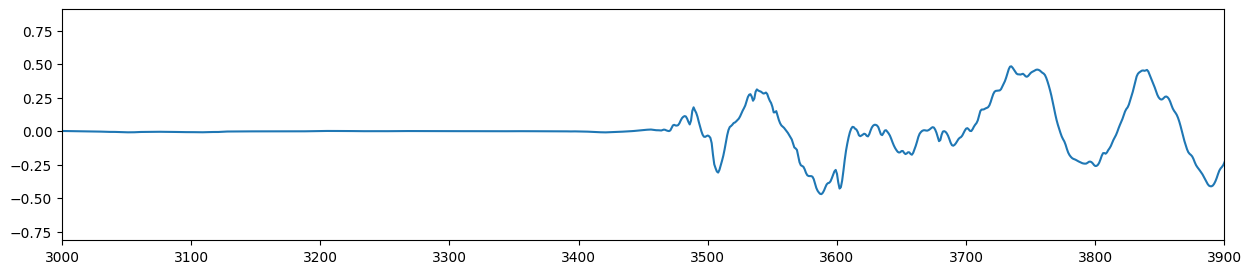

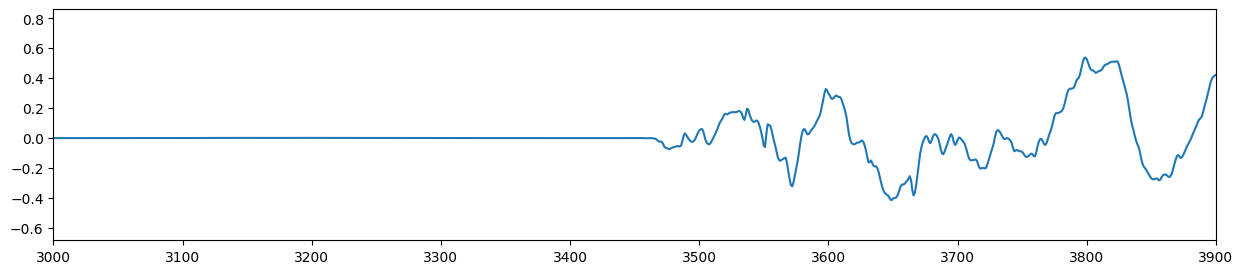

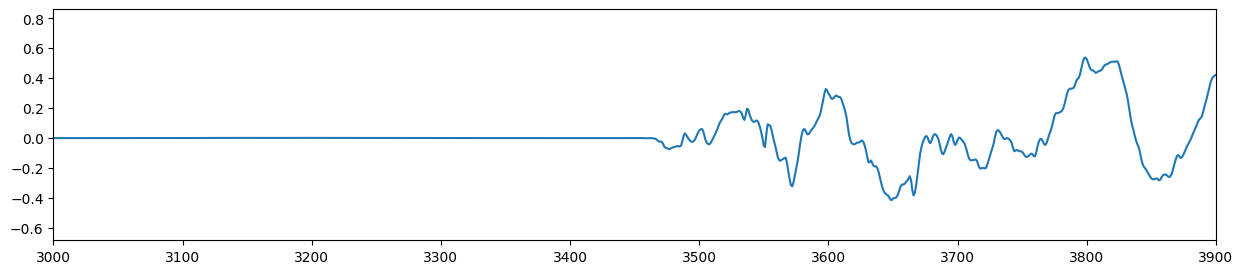

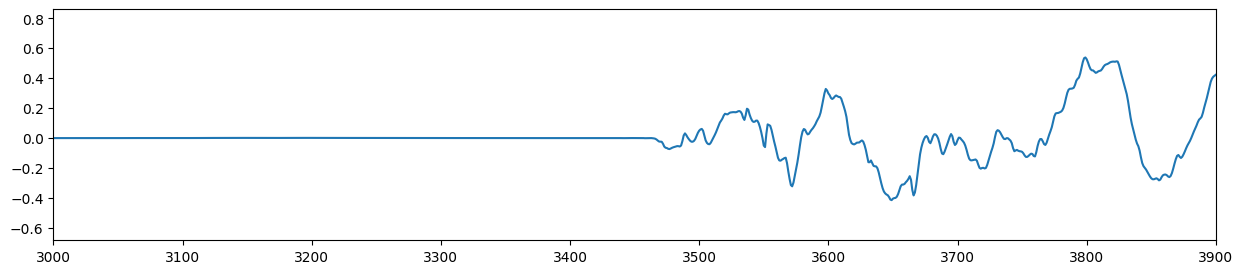

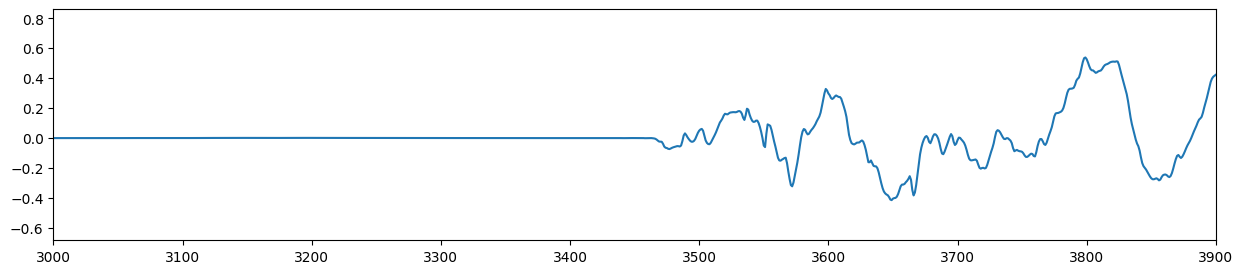

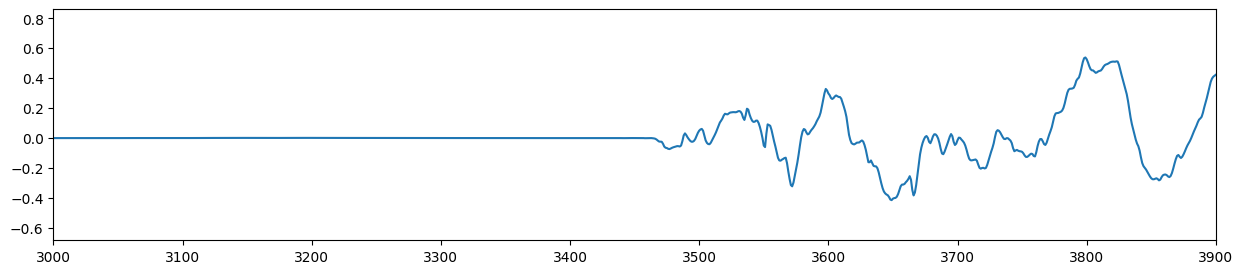

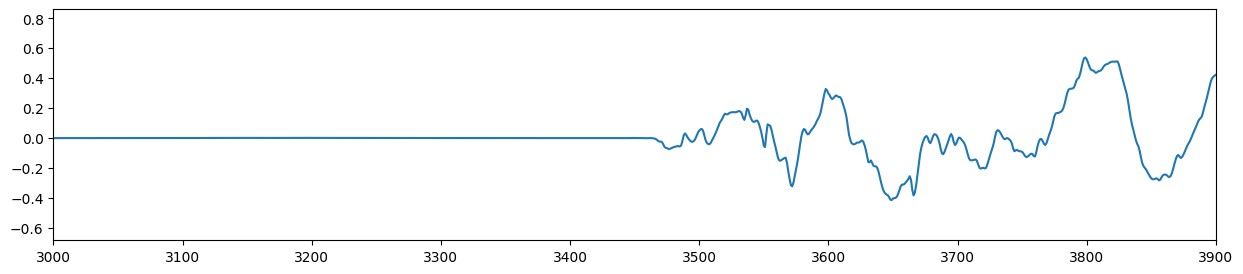

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,3))
plt.plot(checkpoint_forward_normal.squeeze())
plt.xlim(3000, 3900)

plt.figure(figsize=(15,3))

plt.plot(torchscript_forward_big_chunk.squeeze())
plt.xlim(3000, 3900)

plt.figure(figsize=(15,3))
plt.plot(torchscript_forward_big_chunk_os.squeeze())
plt.xlim(3000, 3900)

plt.figure(figsize=(15,3))
plt.plot(torchscript_forward_chunks.squeeze())
plt.xlim(3000, 3900)

plt.figure(figsize=(15,3))
plt.plot(torchscript_full_chunk_by_chunk.squeeze())
plt.xlim(3000, 3900)

import matplotlib.pyplot as plt
plt.figure(figsize=(15,3))
plt.plot(torchscript_forward_chunk_encode.squeeze())
plt.xlim(3000, 3900)
plt.figure(figsize=(15,3))
plt.plot(torchscript_forward_chunk_small.squeeze())
plt.xlim(3000, 3900)


In [ ]:

print("normal checkpoint generation")
display(Audio(to_audio_display(checkpoint_forward_normal), rate=sample_rate))

print("TorchScript decode of checkpoint latents")
display(Audio(to_audio_display(torchscript_decode_checkpoint_latents), rate=sample_rate))

print("streaming TorchScript, one big chunk")
display(Audio(to_audio_display(torchscript_forward_big_chunk), rate=sample_rate))

print("streaming TorchScript, one big chunk")
display(Audio(to_audio_display(torchscript_forward_big_chunk_os), rate=sample_rate))

print("streaming TorchScript, big chunk by chunk")
display(Audio(to_audio_display(torchscript_forward_chunks), rate=sample_rate))

print("streaming TorchScript, small chunk encode - decode full")
display(Audio(to_audio_display(torchscript_forward_chunk_encode), rate=sample_rate))

print("streaming TorchScript, small chunk encode - decode full")
display(Audio(to_audio_display(torchscript_forward_chunk_small), rate=sample_rate))


In [ ]:
reset_stream_state(torchscript_stream_fast)


torchscript_chunks = []
with torch.no_grad():     
    for start in range(0, x_compare_padded.shape[-1], chunk_size_fast):
        chunk = x_compare_padded[..., start:start + chunk_size_fast]
        
        z_fast_cur = torchscript_stream_fast.encode_fast(chunk)
        torchscript_chunks.append(z_fast_cur.detach().cpu())
        
    zf = torch.cat(torchscript_chunks, dim=-1)
    

reset_stream_state(torchscript_stream_fast)
zf2 = torchscript_stream_fast.encode_fast(x_compare_padded)

print((zf-zf2)[0,0])


reset_stream_state(torchscript_stream)

torchscript_chunks = []
with torch.no_grad():     
    for start in range(0, x_compare_padded.shape[-1], chunk_size_slow):
        chunk = x_compare_padded[..., start:start + chunk_size_slow]
        
        z_slow_cur = torchscript_stream.encode_slow(chunk)
        torchscript_chunks.append(z_slow_cur.detach().cpu())
        
    zs = torch.cat(torchscript_chunks, dim=-1)
    

reset_stream_state(torchscript_stream)
zs2 = torchscript_stream.encode_slow(x_compare_padded)

print((zs-zs2)[0,0])

In [ ]:
comparison_out_dir = repo_root / "notebooks" / "doubleae_outputs"
comparison_out_dir.mkdir(parents=True, exist_ok=True)

torchaudio.save(
    str(comparison_out_dir / f"{compare_name}_checkpoint_forward_normal.wav"),
    checkpoint_forward_normal[0].clamp(-1, 1),
    sample_rate,
)
torchaudio.save(
    str(comparison_out_dir / f"{compare_name}_torchscript_decode_checkpoint_latents.wav"),
    torchscript_decode_checkpoint_latents[0].clamp(-1, 1),
    sample_rate,
)
torchaudio.save(
    str(comparison_out_dir / f"{compare_name}_torchscript_forward_big_chunk.wav"),
    torchscript_forward_big_chunk[0].clamp(-1, 1),
    sample_rate,
)
torchaudio.save(
    str(comparison_out_dir / f"{compare_name}_torchscript_forward_chunks.wav"),
    torchscript_forward_chunks[0].clamp(-1, 1),
    sample_rate,
)
torchaudio.save(
    str(comparison_out_dir / f"{compare_name}_checkpoint_vs_torchscript_decode_difference.wav"),
    checkpoint_vs_ts_decode[0].clamp(-1, 1),
    sample_rate,
)
torchaudio.save(
    str(comparison_out_dir / f"{compare_name}_torchscript_big_vs_chunks_difference.wav"),
    big_vs_chunks[0].clamp(-1, 1),
    sample_rate,
)

print(comparison_out_dir)


## Test 64-sample streaming STFT and ISTFT

Check how the fast `StreamableSTFT` reconstructs audio when it is run offline, in one streaming call, and chunk by chunk with 64-sample chunks.


In [ ]:
from after.autoencoder.audio import StreamableSTFT
from after_scripts.export_double_autoencoder import reset_stream_state

stft_name = "darbouka3"
stft_source = examples[stft_name]["audio"].detach().cpu()
stft_original_samples = stft_source.shape[-1]

fast_ref = model.fast_encoder.time_transform
stft_hop = fast_ref.hop_size
stft_pad = (-stft_source.shape[-1]) % stft_hop
stft_input = torch.nn.functional.pad(stft_source, (0, stft_pad)) if stft_pad else stft_source


def make_fast_stft(stream):
    return StreamableSTFT(
        nfft=fast_ref.nfft,
        hop_size=fast_ref.hop_size,
        stream=stream,
        skip_features=fast_ref.skip_features,
        normalize=fast_ref.normalize,
        log1p=fast_ref.log1p,
        alpha_rescale=fast_ref.alpha_rescale,
        beta_rescale=fast_ref.beta_rescale,
    )


def rms(x):
    return torch.sqrt(torch.mean(x.square())).item()


stft_offline = make_fast_stft(stream=False).eval()
stft_stream_big = make_fast_stft(stream=True).eval()
stft_stream_chunks = make_fast_stft(stream=True).eval()

with torch.no_grad():
    spec_offline = stft_offline(stft_input)
    stft_istft_offline = stft_offline.inverse(spec_offline)[..., :stft_original_samples]

reset_stream_state(stft_stream_big)
with torch.no_grad():
    spec_big = stft_stream_big(stft_input)
    stft_istft_stream_big = stft_stream_big.inverse_stream(spec_big)[..., :stft_original_samples]

reset_stream_state(stft_stream_chunks)
stft_chunk_outputs = []
with torch.no_grad():
    for start in range(0, stft_input.shape[-1], stft_hop):
        chunk = stft_input[..., start:start + stft_hop]
        spec_chunk = stft_stream_chunks(chunk)
        stft_chunk_outputs.append(stft_stream_chunks.inverse_stream(spec_chunk).detach().cpu())
stft_istft_stream_chunks = torch.cat(stft_chunk_outputs, dim=-1)[..., :stft_original_samples]

stft_offline_error = stft_source - stft_istft_offline
stft_stream_big_error = stft_source - stft_istft_stream_big
stft_stream_chunks_error = stft_source - stft_istft_stream_chunks
stft_big_vs_chunks = stft_istft_stream_big - stft_istft_stream_chunks

print("Fast STFT settings")
print(f"nfft={fast_ref.nfft}, hop={stft_hop}, stream chunk={stft_hop}")
print(f"skip_features={fast_ref.skip_features}, normalize={fast_ref.normalize}")
print(f"pad={stft_pad}, chunks={stft_input.shape[-1] // stft_hop}")
print(f"offline spec shape: {tuple(spec_offline.shape)}")
print(f"stream big spec shape: {tuple(spec_big.shape)}")
print(f"offline MSE:        {torch.mean(stft_offline_error.square()).item():.6g}")
print(f"stream big MSE:     {torch.mean(stft_stream_big_error.square()).item():.6g}")
print(f"stream chunks MSE:  {torch.mean(stft_stream_chunks_error.square()).item():.6g}")
print(f"big vs chunks MSE:  {torch.mean(stft_big_vs_chunks.square()).item():.6g}")
print(f"source RMS:         {rms(stft_source):.6g}")
print(f"offline RMS:        {rms(stft_istft_offline):.6g}")
print(f"stream big RMS:     {rms(stft_istft_stream_big):.6g}")
print(f"stream chunks RMS:  {rms(stft_istft_stream_chunks):.6g}")

print("original")
display(Audio(to_audio_display(stft_source), rate=sample_rate))

print("offline STFT -> ISTFT")
display(Audio(to_audio_display(stft_istft_offline), rate=sample_rate))

print("streaming STFT -> ISTFT, one call")
display(Audio(to_audio_display(stft_istft_stream_big), rate=sample_rate))

print("streaming STFT -> ISTFT, 64-sample chunks")
display(Audio(to_audio_display(stft_istft_stream_chunks), rate=sample_rate))

print("streaming one-call minus 64-sample chunks")
display(Audio(to_audio_display(stft_big_vs_chunks), rate=sample_rate))


In [ ]:
stft_out_dir = repo_root / "notebooks" / "doubleae_outputs"
stft_out_dir.mkdir(parents=True, exist_ok=True)

torchaudio.save(
    str(stft_out_dir / f"{stft_name}_stft_istft_offline.wav"),
    stft_istft_offline[0].clamp(-1, 1),
    sample_rate,
)
torchaudio.save(
    str(stft_out_dir / f"{stft_name}_stft_istft_stream_big.wav"),
    stft_istft_stream_big[0].clamp(-1, 1),
    sample_rate,
)
torchaudio.save(
    str(stft_out_dir / f"{stft_name}_stft_istft_stream_64_chunks.wav"),
    stft_istft_stream_chunks[0].clamp(-1, 1),
    sample_rate,
)
torchaudio.save(
    str(stft_out_dir / f"{stft_name}_stft_stream_big_vs_64_chunks.wav"),
    stft_big_vs_chunks[0].clamp(-1, 1),
    sample_rate,
)

print(stft_out_dir)
